### How are in-demand skills trending for Data Analysts?

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [44]:
#Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading the dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [45]:
df_DA=df[df['job_title']=='Data Analyst'].copy()

In [46]:
df_DA['job_posted_month_no']=df_DA['job_posted_date'].dt.month

In [47]:
df_DA_explode=df_DA.explode('job_skills')

In [48]:
df_DA_pivot=df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_pivot.loc['Total']=df_DA_pivot.sum()
df_DA_pivot=df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot=df_DA_pivot.drop('Total')

In [49]:
df_totals=df_DA.groupby('job_posted_month_no').size()

In [50]:
df_DA_percent=df_DA_pivot.div(df_totals/100, axis=0)

In [51]:
#change job_posted_month_no to month name
month_names={1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

df_DA_percent.index=df_DA_percent.index.map(month_names)
df_DA_percent

job_skills,sql,excel,python,tableau,power bi,r,sas,azure,powerpoint,word,...,chainer,debian,pascal,mxnet,next.js,nuix,suse,svelte,twilio,wsl
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
Jan,58.577742,36.560868,32.965046,29.610285,22.378465,17.095219,18.320611,6.126959,6.528726,5.825633,...,0.000000,0.020088,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,57.829912,36.158358,33.431085,28.299120,23.607038,17.272727,17.008798,7.478006,6.715543,6.217009,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.029326
Mar,57.940042,36.895221,33.095874,30.335411,23.983378,17.393885,16.503413,6.055209,6.559810,6.589492,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.029682,0.000000,0.000000,0.000000
Apr,59.361572,37.507673,34.653161,29.465930,23.112339,17.771639,15.715163,5.985267,6.599141,7.213014,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,61.120318,37.620152,35.034803,29.366921,23.864766,18.495194,13.258204,6.065628,6.496520,5.535300,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,59.364797,36.746809,35.173642,29.504304,25.794004,18.670229,14.959929,6.173939,6.262986,6.678540,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,59.204759,37.789606,35.754540,29.555416,24.201628,19.035692,14.214152,6.011271,6.073889,6.073889,...,0.000000,0.000000,0.031309,0.000000,0.031309,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,56.025267,37.342080,33.965015,29.373178,25.072886,18.148688,13.848397,5.685131,5.466472,5.126336,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,54.909882,35.363580,32.349285,27.439403,25.108763,16.190180,13.238036,5.686762,3.946551,4.101927,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.031075,0.000000,0.000000,0.000000,0.000000


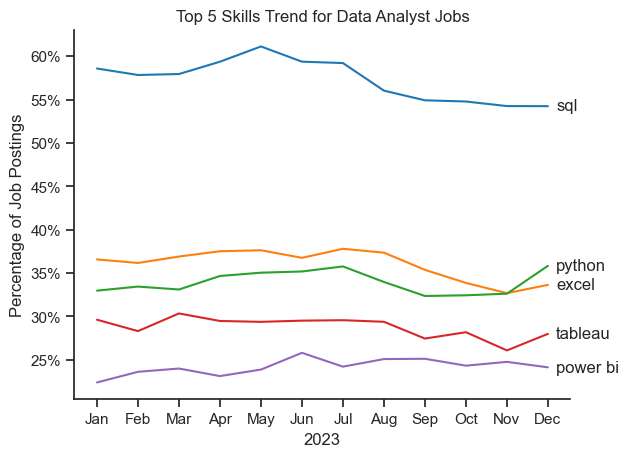

In [58]:
df_plot=df_DA_percent.iloc[:,:5]
sns.lineplot(data=df_plot,dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()
plt.title('Top 5 Skills Trend for Data Analyst Jobs')
plt.xlabel('2023')
plt.ylabel('Percentage of Job Postings')
plt.legend().remove()

ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], va='center')
plt.show()